In [1]:
import pandas as pd

from Pipeline.Methodology.BayesianAnalysis import BayesianAnalysis
from Pipeline.Methodology import ABC_Testing

In [2]:
model_files = {
    "ABC RELM CV"   : "cleaned_ABC_RELM_CV_Algo_3_2_80SN_120MI_Results.csv",
    "MLP"           : "cleaned_MLP_Results.csv",
    "ELM"           : "cleaned_Best_Hidden_Nodes_Results.csv",
    "RELM"          : "cleaned_Grid_Optimization_Results.csv",
    "ABC RELM IE"   : "cleaned_ABC_RELM_Algo_3_2_80SN_120MI_Results.csv",
    "ABC RELM CE"   : "cleaned_ABC_RELM_CV_Ensemble_Algo_3_2_80SN_120MI_Results.csv",
    "RF"            : "cleaned_RF_Results.csv",
    "HGBC"          : "cleaned_HGBC_Results.csv",
    "LRC"           : "cleaned_LogReg_Classifier_Results.csv",
    "Linear SVC"    : "cleaned_LinearSVC_Results.csv",
}
baseline = [
    "MLP",
    "HGBC",
    "RELM",
    "RF",
    "ELM",
    "ABC RELM IE",
    "ABC RELM CE",
    "Linear SVC",
    "LRC",
]

In [3]:
unused_column = [
        'Hidden_Nodes', 'Lambda_Value',
        'Solution_Size', 'Trial_Limit', 'Max_Iteration',
        'Precision', 'Recall', 'NPV', 'Specificity',
        'F2-Score', 'Bal Accuracy'
    ]

In [4]:
result_summary = ABC_Testing.overall_result_summaries(model_files,unused_column)

[I/O Trace] Bayesian Summary Figure exported: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Report Figure\Bayesian_Summary_Bayesian_Summary_MCC.png


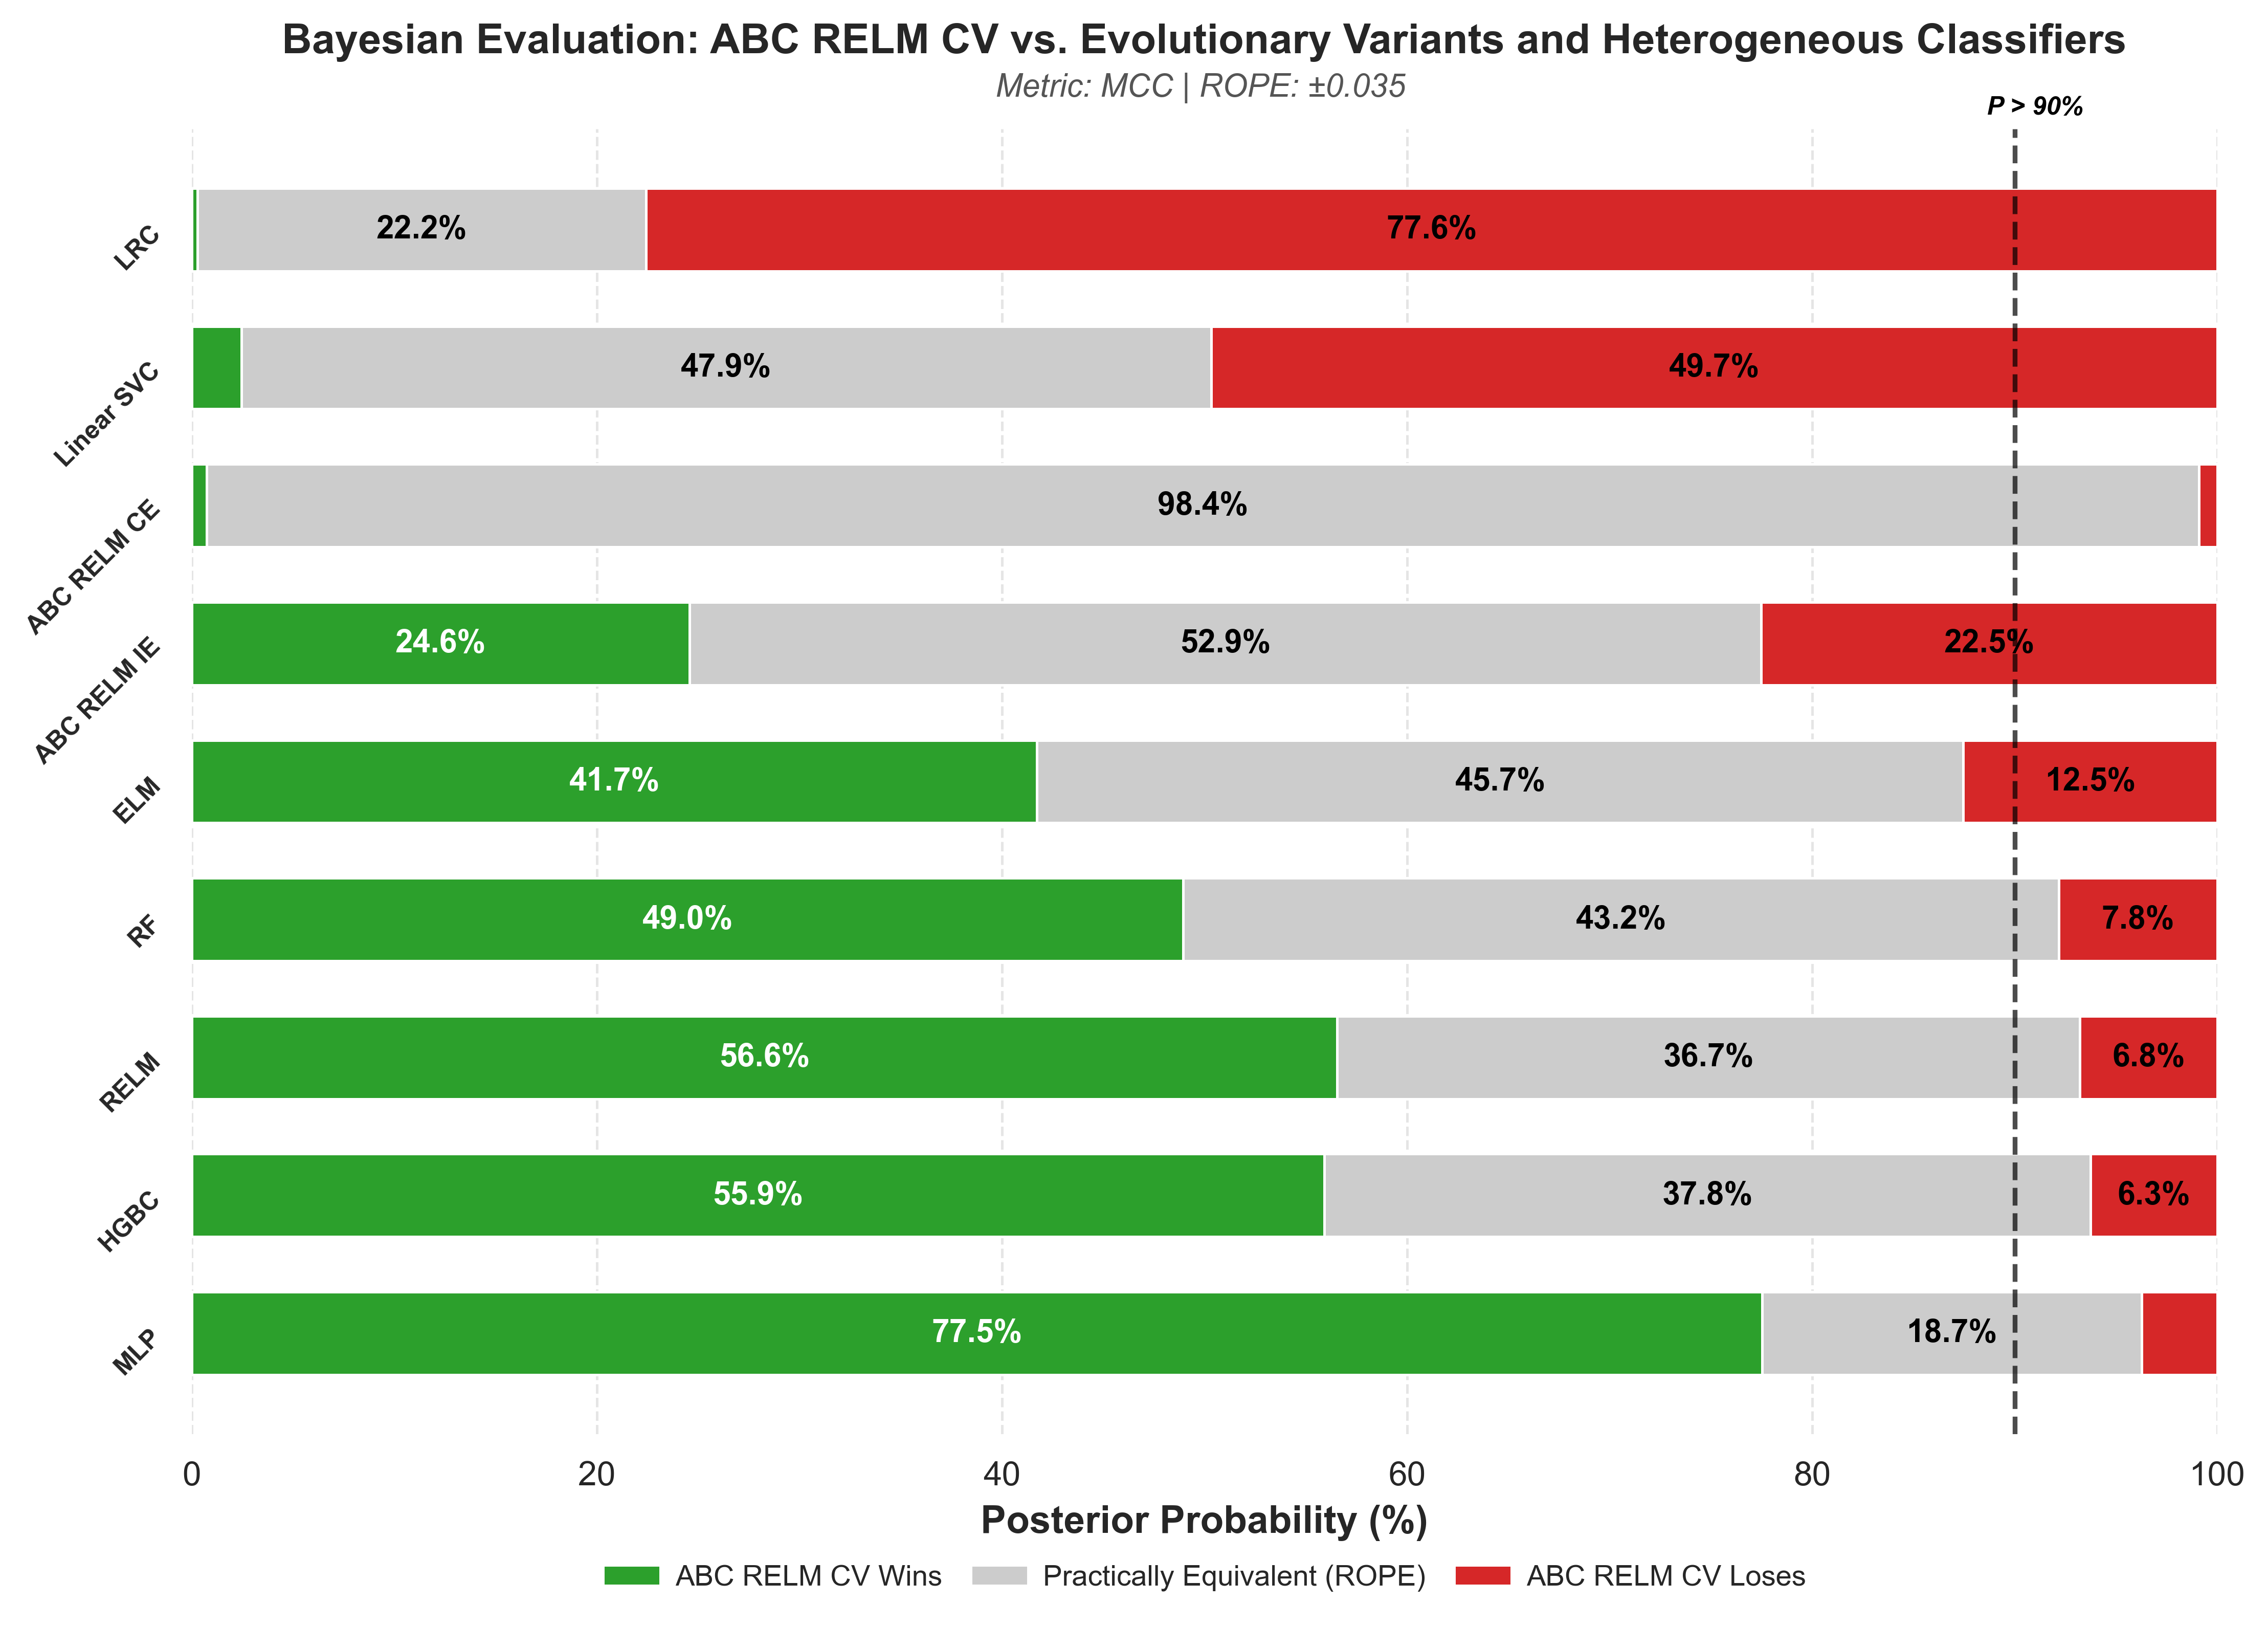

In [5]:
bayesian_result = BayesianAnalysis.run_bayesian_evaluation(
    model_dict      = model_files,
    champion_model  = "ABC RELM CV",
    baselines       = baseline,
    title           = "Bayesian Evaluation: ABC RELM CV vs. Evolutionary Variants and Heterogeneous Classifiers",
    metric_name     = 'MCC',
    rope_radius     = 0.035,
    certainty_threshold = 0.9,
    is_final_record     = True
)

In [6]:
final_result_summary = final_df = result_summary.merge(bayesian_result[['P_Win']],
                         left_on='model_name', right_index=True, how='left')

In [7]:
sequence_baseline = baseline[::-1]
full_order = ["ABC RELM CV"] + sequence_baseline

final_result_summary['model_name'] = pd.Categorical(
    final_result_summary['model_name'],
    categories = full_order,
    ordered = True
)
final_result_summary = final_result_summary.sort_values('model_name')

report_summary = ABC_Testing.format_summaries_for_academic_report(final_result_summary)
report_summary

,model_name,Accuracy,F1-Score,MCC,P_Win
0,ABC RELM CV,0.7943 ± 0.0433,0.7739 ± 0.0483,0.5962 ± 0.0877,NaN
8,LRC,0.8269 ± 0.0493,0.8136 ± 0.0589,0.6572 ± 0.0962,0.002736
9,Linear SVC,0.8143 ± 0.0583,0.8018 ± 0.0652,0.6309 ± 0.1163,0.024539
5,ABC RELM CE,0.7945 ± 0.0437,0.7741 ± 0.0484,0.5967 ± 0.0884,0.007376
4,ABC RELM IE,0.7934 ± 0.0355,0.7723 ± 0.0417,0.5946 ± 0.0707,0.245713
2,ELM,0.7823 ± 0.0310,0.7612 ± 0.0365,0.5720 ± 0.0616,0.417331
6,RF,0.7804 ± 0.0326,0.7707 ± 0.0289,0.5625 ± 0.0661,0.489536
3,RELM,0.7733 ± 0.0317,0.7532 ± 0.0347,0.5525 ± 0.0641,0.565528
7,HGBC,0.7756 ± 0.0286,0.7635 ± 0.0287,0.5537 ± 0.0569,0.559257
1,MLP,0.7487 ± 0.0442,0.7394 ± 0.0420,0.5098 ± 0.0872,0.775336
